# Import required libraries

In [1]:
import pyodbc
import sys
sys.path.append("../..")
from utility.sql_utilities import SQLUtilities as ut

# Create Connection and Cursor for MyDatabase and SalesDB Databases

In [2]:
mydb_connector = pyodbc.connect("Driver={ODBC Driver 17 for SQL Server};" "Server=BRIGHT-WORK\\SQLEXPRESS;" "Database=MyDatabase;" "Trusted_Connection=yes;")
mydb_cursor = mydb_connector.cursor()

salesdb_connector = pyodbc.connect("Driver={ODBC Driver 17 for SQL Server};" "Server=BRIGHT-WORK\\SQLEXPRESS;" "Database=SalesDB;" "Trusted_Connection=yes;")
salesdb_cursor = salesdb_connector.cursor()

# String functions

In [3]:
select_query: str = """
-- Concatenate first name and country into one column
SELECT 
    CONCAT(first_name, '-', country) AS full_info
FROM customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

select_query: str = """
-- Convert the first name to lowercase
SELECT 
    LOWER(first_name) AS lower_case_name
FROM customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

select_query: str = """
-- Convert the first name to uppercase
SELECT 
    UPPER(first_name) AS upper_case_name
FROM customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

+----------------+
|   full_info    |
+----------------+
| Maria-Germany  |
|    John-USA    |
|    Georg-UK    |
| Martin-Germany |
|   Peter-USA    |
+----------------+
5 rows returned in time: (0.081 sec)


+-----------------+
| lower_case_name |
+-----------------+
|      maria      |
|       john      |
|      georg      |
|     martin      |
|      peter      |
+-----------------+
5 rows returned in time: (0.003 sec)


+-----------------+
| upper_case_name |
+-----------------+
|      MARIA      |
|       JOHN      |
|      GEORG      |
|     MARTIN      |
|      PETER      |
+-----------------+
5 rows returned in time: (0.002 sec)




In [4]:
select_query: str = """
-- Find customers whose first name contains leading or trailing spaces
SELECT 
    first_name,
	LEN(first_name) AS len_name,
	LEN(TRIM(first_name)) AS len_trim_name,
	LEN(first_name) - LEN(TRIM(first_name)) AS flag
FROM customers
WHERE LEN(first_name)  != LEN(TRIM(first_name))
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

# Remove dashes (-) from a phone number
select_query: str = """
SELECT
'123-456-7890' AS phone,
REPLACE('123-456-7890', '-', '/') AS clean_phone
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

# Replace File Extence from txt to csv 
select_query: str = """
SELECT
'report.txt' AS old_filename,
REPLACE('report.txt', '.txt', '.csv') AS new_filename
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

# Calculate the length of each customer's first name
select_query: str = """
SELECT 
    first_name, 
    LEN(first_name) AS name_length
FROM customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

+------------+----------+---------------+------+
| first_name | len_name | len_trim_name | flag |
+------------+----------+---------------+------+
|    John    |    5     |       4       |  1   |
+------------+----------+---------------+------+
1 row returned in time: (0.017 sec)


+--------------+--------------+
|    phone     | clean_phone  |
+--------------+--------------+
| 123-456-7890 | 123/456/7890 |
+--------------+--------------+
1 row returned in time: (0.002 sec)


+--------------+--------------+
| old_filename | new_filename |
+--------------+--------------+
|  report.txt  |  report.csv  |
+--------------+--------------+
1 row returned in time: (0.0 sec)


+------------+-------------+
| first_name | name_length |
+------------+-------------+
|   Maria    |      5      |
|    John    |      5      |
|   Georg    |      5      |
|   Martin   |      6      |
|   Peter    |      5      |
+------------+-------------+
5 rows returned in time: (0.002 sec)




In [5]:
# Retrieve the first two characters of each first name
select_query: str = """
SELECT 
    first_name,
    LEFT(TRIM(first_name), 2) AS first_2_chars
FROM customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

# Retrieve the last two characters of each first name
select_query: str = """
SELECT 
    first_name,
    RIGHT(TRIM(first_name), 2) AS last_2_chars
FROM customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

# Retrieve a list of customers' first names after removing the first character
select_query: str = """
SELECT 
    first_name,
    SUBSTRING(TRIM(first_name), 2, LEN(first_name)) AS trimmed_name
FROM customers	
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

+------------+---------------+
| first_name | first_2_chars |
+------------+---------------+
|   Maria    |      Ma       |
|    John    |      Jo       |
|   Georg    |      Ge       |
|   Martin   |      Ma       |
|   Peter    |      Pe       |
+------------+---------------+
5 rows returned in time: (0.007 sec)


+------------+--------------+
| first_name | last_2_chars |
+------------+--------------+
|   Maria    |      ia      |
|    John    |      hn      |
|   Georg    |      rg      |
|   Martin   |      in      |
|   Peter    |      er      |
+------------+--------------+
5 rows returned in time: (0.002 sec)


+------------+--------------+
| first_name | trimmed_name |
+------------+--------------+
|   Maria    |     aria     |
|    John    |     ohn      |
|   Georg    |     eorg     |
|   Martin   |    artin     |
|   Peter    |     eter     |
+------------+--------------+
5 rows returned in time: (0.005 sec)




# Number Functions

In [6]:
# Demonstrate rounding a number to different decimal places
select_query: str = """
SELECT 
    3.516 AS original_number,
    ROUND(3.516, 2) AS round_2,
    ROUND(3.516, 1) AS round_1,
    ROUND(3.516, 0) AS round_0	
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)


# Demonstrate absolute value function
select_query: str = """
SELECT 
    -10 AS original_number,
    ABS(-10) AS absolute_value_negative,
    ABS(10) AS absolute_value_positive	
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

+-----------------+---------+---------+---------+
| original_number | round_2 | round_1 | round_0 |
+-----------------+---------+---------+---------+
|      3.516      |  3.520  |  3.500  |  4.000  |
+-----------------+---------+---------+---------+
1 row returned in time: (0.004 sec)


+-----------------+-------------------------+-------------------------+
| original_number | absolute_value_negative | absolute_value_positive |
+-----------------+-------------------------+-------------------------+
|       -10       |           10            |           10            |
+-----------------+-------------------------+-------------------------+
1 row returned in time: (0.001 sec)




# Date_Time Functions

In [7]:
# TASK 1: Display OrderID, CreationTime, a hard-coded date, and the current system date.
select_query: str = """
SELECT
    OrderID,
    CreationTime,
    '2025-08-20' AS HardCoded,
    GETDATE() AS Today
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+---------------------+------------+----------------------------+
| OrderID |    CreationTime     | HardCoded  |           Today            |
+---------+---------------------+------------+----------------------------+
|    1    | 2025-01-01 12:34:56 | 2025-08-20 | 2025-04-14 14:55:39.700000 |
|    2    | 2025-01-05 23:22:04 | 2025-08-20 | 2025-04-14 14:55:39.700000 |
|    3    | 2025-01-10 18:24:08 | 2025-08-20 | 2025-04-14 14:55:39.700000 |
|    4    | 2025-01-20 05:50:33 | 2025-08-20 | 2025-04-14 14:55:39.700000 |
|    5    | 2025-02-01 14:02:41 | 2025-08-20 | 2025-04-14 14:55:39.700000 |
|    6    | 2025-02-06 15:34:57 | 2025-08-20 | 2025-04-14 14:55:39.700000 |
|    7    | 2025-02-16 06:22:01 | 2025-08-20 | 2025-04-14 14:55:39.700000 |
|    8    | 2025-02-18 10:45:22 | 2025-08-20 | 2025-04-14 14:55:39.700000 |
|    9    | 2025-03-10 12:59:04 | 2025-08-20 | 2025-04-14 14:55:39.700000 |
|   10    | 2025-03-16 23:25:15 | 2025-08-20 | 2025-04-14 14:55:39.700000 |
+---------+-

In [8]:
# TASK 2: Extract various parts of CreationTime using DATETRUNC, DATENAME, DATEPART, YEAR, MONTH, and DAY.
select_query: str = """
SELECT
    OrderID,
    CreationTime,
    -- DATETRUNC Examples
    DATETRUNC(year, CreationTime) AS Year_dt,
    DATETRUNC(day, CreationTime) AS Day_dt,
    DATETRUNC(minute, CreationTime) AS Minute_dt,
    -- DATENAME Examples
    DATENAME(month, CreationTime) AS Month_dn,
    DATENAME(weekday, CreationTime) AS Weekday_dn,
    DATENAME(day, CreationTime) AS Day_dn,
    DATENAME(year, CreationTime) AS Year_dn,
    -- DATEPART Examples
    DATEPART(year, CreationTime) AS Year_dp,
    DATEPART(month, CreationTime) AS Month_dp,
    DATEPART(day, CreationTime) AS Day_dp,
    DATEPART(hour, CreationTime) AS Hour_dp,
    DATEPART(quarter, CreationTime) AS Quarter_dp,
    DATEPART(week, CreationTime) AS Week_dp,
    YEAR(CreationTime) AS Year,
    MONTH(CreationTime) AS Month,
    DAY(CreationTime) AS Day
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+---------------------+---------------------+---------------------+---------------------+----------+------------+--------+---------+---------+----------+--------+---------+------------+---------+------+-------+-----+
| OrderID |    CreationTime     |       Year_dt       |       Day_dt        |      Minute_dt      | Month_dn | Weekday_dn | Day_dn | Year_dn | Year_dp | Month_dp | Day_dp | Hour_dp | Quarter_dp | Week_dp | Year | Month | Day |
+---------+---------------------+---------------------+---------------------+---------------------+----------+------------+--------+---------+---------+----------+--------+---------+------------+---------+------+-------+-----+
|    1    | 2025-01-01 12:34:56 | 2025-01-01 00:00:00 | 2025-01-01 00:00:00 | 2025-01-01 12:34:00 | January  | Wednesday  |   1    |  2025   |  2025   |    1     |   1    |   12    |     1      |    1    | 2025 |   1   |  1  |
|    2    | 2025-01-05 23:22:04 | 2025-01-01 00:00:00 | 2025-01-05 00:00:00 | 2025-01-05 23:

In [9]:
# TASK 3: Aggregate orders by year using DATETRUNC on CreationTime.
select_query: str = """
SELECT
    DATETRUNC(year, CreationTime) AS Creation,
    COUNT(*) AS OrderCount
FROM Sales.Orders
GROUP BY DATETRUNC(year, CreationTime);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------------------+------------+
|      Creation       | OrderCount |
+---------------------+------------+
| 2025-01-01 00:00:00 |     10     |
+---------------------+------------+
1 row returned in time: (0.022 sec)




In [10]:
# TASK 4: Display OrderID, CreationTime, and the end-of-month date for CreationTime.
select_query: str = """
SELECT
    OrderID,
    CreationTime,
    EOMONTH(CreationTime) AS EndOfMonth
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

# TASK 5: How many orders were placed each year?
select_query: str = """
SELECT 
    YEAR(OrderDate) AS OrderYear, 
    COUNT(*) AS TotalOrders
FROM Sales.Orders
GROUP BY YEAR(OrderDate);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

# TASK 6: How many orders were placed each month?
select_query: str = """
SELECT 
    MONTH(OrderDate) AS OrderMonth, 
    COUNT(*) AS TotalOrders
FROM Sales.Orders
GROUP BY MONTH(OrderDate);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
SELECT 
    DATENAME(month, OrderDate) AS OrderMonth, 
    COUNT(*) AS TotalOrders
FROM Sales.Orders
GROUP BY DATENAME(month, OrderDate);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+---------------------+------------+
| OrderID |    CreationTime     | EndOfMonth |
+---------+---------------------+------------+
|    1    | 2025-01-01 12:34:56 | 2025-01-31 |
|    2    | 2025-01-05 23:22:04 | 2025-01-31 |
|    3    | 2025-01-10 18:24:08 | 2025-01-31 |
|    4    | 2025-01-20 05:50:33 | 2025-01-31 |
|    5    | 2025-02-01 14:02:41 | 2025-02-28 |
|    6    | 2025-02-06 15:34:57 | 2025-02-28 |
|    7    | 2025-02-16 06:22:01 | 2025-02-28 |
|    8    | 2025-02-18 10:45:22 | 2025-02-28 |
|    9    | 2025-03-10 12:59:04 | 2025-03-31 |
|   10    | 2025-03-16 23:25:15 | 2025-03-31 |
+---------+---------------------+------------+
10 rows returned in time: (0.013 sec)


+-----------+-------------+
| OrderYear | TotalOrders |
+-----------+-------------+
|   2025    |     10      |
+-----------+-------------+
1 row returned in time: (0.007 sec)


+------------+-------------+
| OrderMonth | TotalOrders |
+------------+-------------+
|     1      |      4      |
|     2 

In [11]:
# Format CreationTime into various string representations.
select_query: str = """
SELECT
    OrderID,
    CreationTime,
    FORMAT(CreationTime, 'MM-dd-yyyy') AS USA_Format,
    FORMAT(CreationTime, 'dd-MM-yyyy') AS EURO_Format,
    FORMAT(CreationTime, 'dd') AS dd,
    FORMAT(CreationTime, 'ddd') AS ddd,
    FORMAT(CreationTime, 'dddd') AS dddd,
    FORMAT(CreationTime, 'MM') AS MM,
    FORMAT(CreationTime, 'MMM') AS MMM,
    FORMAT(CreationTime, 'MMMM') AS MMMM
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+---------------------+------------+-------------+----+-----+-----------+----+-----+----------+
| OrderID |    CreationTime     | USA_Format | EURO_Format | dd | ddd |   dddd    | MM | MMM |   MMMM   |
+---------+---------------------+------------+-------------+----+-----+-----------+----+-----+----------+
|    1    | 2025-01-01 12:34:56 | 01-01-2025 | 01-01-2025  | 01 | Wed | Wednesday | 01 | Jan | January  |
|    2    | 2025-01-05 23:22:04 | 01-05-2025 | 05-01-2025  | 05 | Sun |  Sunday   | 01 | Jan | January  |
|    3    | 2025-01-10 18:24:08 | 01-10-2025 | 10-01-2025  | 10 | Fri |  Friday   | 01 | Jan | January  |
|    4    | 2025-01-20 05:50:33 | 01-20-2025 | 20-01-2025  | 20 | Mon |  Monday   | 01 | Jan | January  |
|    5    | 2025-02-01 14:02:41 | 02-01-2025 | 01-02-2025  | 01 | Sat | Saturday  | 02 | Feb | February |
|    6    | 2025-02-06 15:34:57 | 02-06-2025 | 06-02-2025  | 06 | Thu | Thursday  | 02 | Feb | February |
|    7    | 2025-02-16 06:22:01 | 02-16-2025 |

In [12]:
# Display CreationTime using a custom format: Example: Day Wed Jan Q1 2025 12:34:56 PM
select_query: str = """
SELECT
    OrderID,
    CreationTime,
    'Day ' + FORMAT(CreationTime, 'ddd MMM') +
    ' Q' + DATENAME(quarter, CreationTime) + ' ' +
    FORMAT(CreationTime, 'yyyy hh:mm:ss tt') AS CustomFormat
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

#TASK 11: How many orders were placed each year, formatted by month and year (e.g., "Jan 25")?
select_query: str = """
SELECT
    FORMAT(CreationTime, 'MMM yy') AS OrderDate,
    COUNT(*) AS TotalOrders
FROM Sales.Orders
GROUP BY FORMAT(CreationTime, 'MMM yy');
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+---------------------+---------------------------------+
| OrderID |    CreationTime     |          CustomFormat           |
+---------+---------------------+---------------------------------+
|    1    | 2025-01-01 12:34:56 | Day Wed Jan Q1 2025 12:34:56 PM |
|    2    | 2025-01-05 23:22:04 | Day Sun Jan Q1 2025 11:22:04 PM |
|    3    | 2025-01-10 18:24:08 | Day Fri Jan Q1 2025 06:24:08 PM |
|    4    | 2025-01-20 05:50:33 | Day Mon Jan Q1 2025 05:50:33 AM |
|    5    | 2025-02-01 14:02:41 | Day Sat Feb Q1 2025 02:02:41 PM |
|    6    | 2025-02-06 15:34:57 | Day Thu Feb Q1 2025 03:34:57 PM |
|    7    | 2025-02-16 06:22:01 | Day Sun Feb Q1 2025 06:22:01 AM |
|    8    | 2025-02-18 10:45:22 | Day Tue Feb Q1 2025 10:45:22 AM |
|    9    | 2025-03-10 12:59:04 | Day Mon Mar Q1 2025 12:59:04 PM |
|   10    | 2025-03-16 23:25:15 | Day Sun Mar Q1 2025 11:25:15 PM |
+---------+---------------------+---------------------------------+
10 rows returned in time: (0.021 sec)


+-------

In [13]:
#TASK 11: How many orders were placed each year, formatted by month and year (e.g., "Jan 25")?
select_query: str = """
SELECT
    CONVERT(INT, '123') AS [String to Int CONVERT],
    CONVERT(DATE, '2025-08-20') AS [String to Date CONVERT],
    CreationTime,
    CONVERT(DATE, CreationTime) AS [Datetime to Date CONVERT],
    CONVERT(VARCHAR, CreationTime, 32) AS [USA Std. Style:32],
    CONVERT(VARCHAR, CreationTime, 34) AS [EURO Std. Style:34]
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+-----------------------+------------------------+---------------------+--------------------------+-------------------+--------------------+
| String to Int CONVERT | String to Date CONVERT |    CreationTime     | Datetime to Date CONVERT | USA Std. Style:32 | EURO Std. Style:34 |
+-----------------------+------------------------+---------------------+--------------------------+-------------------+--------------------+
|          123          |       2025-08-20       | 2025-01-01 12:34:56 |        2025-01-01        |    01-01-2025     |     01-01-2025     |
|          123          |       2025-08-20       | 2025-01-05 23:22:04 |        2025-01-05        |    01-05-2025     |     05-01-2025     |
|          123          |       2025-08-20       | 2025-01-10 18:24:08 |        2025-01-10        |    01-10-2025     |     10-01-2025     |
|          123          |       2025-08-20       | 2025-01-20 05:50:33 |        2025-01-20        |    01-20-2025     |     20-01-2025     |
|          12

In [14]:
#TASK 12: Perform date arithmetic on OrderDate
select_query: str = """
SELECT
    OrderID,
    OrderDate,
    DATEADD(day, -10, OrderDate) AS TenDaysBefore,
    DATEADD(month, 3, OrderDate) AS ThreeMonthsLater,
    DATEADD(year, 2, OrderDate) AS TwoYearsLater
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


#TASK 13:  Find the average shipping duration in days for each month.
select_query: str = """
SELECT
    MONTH(OrderDate) AS OrderMonth,
    AVG(DATEDIFF(day, OrderDate, ShipDate)) AS AvgShip
FROM Sales.Orders
GROUP BY MONTH(OrderDate);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

#TASK 14:  Time Gap Analysis: Find the number of days between each order and the previous order.
select_query: str = """
SELECT
    OrderID,
    OrderDate AS CurrentOrderDate,
    LAG(OrderDate) OVER (ORDER BY OrderDate) AS PreviousOrderDate,
    DATEDIFF(day, LAG(OrderDate) OVER (ORDER BY OrderDate), OrderDate) AS NrOfDays
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+------------+---------------+------------------+---------------+
| OrderID | OrderDate  | TenDaysBefore | ThreeMonthsLater | TwoYearsLater |
+---------+------------+---------------+------------------+---------------+
|    1    | 2025-01-01 |  2024-12-22   |    2025-04-01    |  2027-01-01   |
|    2    | 2025-01-05 |  2024-12-26   |    2025-04-05    |  2027-01-05   |
|    3    | 2025-01-10 |  2024-12-31   |    2025-04-10    |  2027-01-10   |
|    4    | 2025-01-20 |  2025-01-10   |    2025-04-20    |  2027-01-20   |
|    5    | 2025-02-01 |  2025-01-22   |    2025-05-01    |  2027-02-01   |
|    6    | 2025-02-05 |  2025-01-26   |    2025-05-05    |  2027-02-05   |
|    7    | 2025-02-15 |  2025-02-05   |    2025-05-15    |  2027-02-15   |
|    8    | 2025-02-18 |  2025-02-08   |    2025-05-18    |  2027-02-18   |
|    9    | 2025-03-10 |  2025-02-28   |    2025-06-10    |  2027-03-10   |
|   10    | 2025-03-15 |  2025-03-05   |    2025-06-15    |  2027-03-15   |
+---------+-

In [15]:
#TASK 15: Calculate the age of employees.
select_query: str = """
SELECT
    EmployeeID,
    BirthDate,
    DATEDIFF(year, BirthDate, GETDATE()) AS Age,
    DATEDIFF(year, GETDATE(), BirthDate) AS AgeTwo
FROM Sales.Employees;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+------------+-----+--------+
| EmployeeID | BirthDate  | Age | AgeTwo |
+------------+------------+-----+--------+
|     1      | 1988-12-05 | 37  |  -37   |
|     2      | 1972-11-25 | 53  |  -53   |
|     3      | 1986-01-05 | 39  |  -39   |
|     4      | 1977-02-10 | 48  |  -48   |
|     5      | 1982-02-11 | 43  |  -43   |
+------------+------------+-----+--------+
5 rows returned in time: (0.023 sec)




In [16]:
#TASK 16: Time Gap Analysis: Find the number of days between each order and the previous order.
select_query: str = """
SELECT
    OrderID,
    OrderDate AS CurrentOrderDate,
    LAG(OrderDate) OVER (ORDER BY OrderDate) AS PreviousOrderDate,
    DATEDIFF(day, LAG(OrderDate) OVER (ORDER BY OrderDate), OrderDate) AS NrOfDays
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+------------------+-------------------+----------+
| OrderID | CurrentOrderDate | PreviousOrderDate | NrOfDays |
+---------+------------------+-------------------+----------+
|    1    |    2025-01-01    |       NULL        |   NULL   |
|    2    |    2025-01-05    |    2025-01-01     |    4     |
|    3    |    2025-01-10    |    2025-01-05     |    5     |
|    4    |    2025-01-20    |    2025-01-10     |    10    |
|    5    |    2025-02-01    |    2025-01-20     |    12    |
|    6    |    2025-02-05    |    2025-02-01     |    4     |
|    7    |    2025-02-15    |    2025-02-05     |    10    |
|    8    |    2025-02-18    |    2025-02-15     |    3     |
|    9    |    2025-03-10    |    2025-02-18     |    20    |
|   10    |    2025-03-15    |    2025-03-10     |    5     |
+---------+------------------+-------------------+----------+
10 rows returned in time: (0.01 sec)




In [17]:
select_query: str = """
SELECT 
    'Year' AS DatePart, 
    DATEPART(year, GETDATE()) AS DatePart_Output,
    DATENAME(year, GETDATE()) AS DateName_Output,
    DATETRUNC(year, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'YY', 
    DATEPART(yy, GETDATE()) AS DatePart_Output,
    DATENAME(yy, GETDATE()) AS DateName_Output, 
    DATETRUNC(yy, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'YYYY', 
    DATEPART(yyyy, GETDATE()) AS DatePart_Output,
    DATENAME(yyyy, GETDATE()) AS DateName_Output, 
    DATETRUNC(yyyy, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'Quarter', 
    DATEPART(quarter, GETDATE()) AS DatePart_Output,
    DATENAME(quarter, GETDATE()) AS DateName_Output, 
    DATETRUNC(quarter, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'QQ', 
    DATEPART(qq, GETDATE()) AS DatePart_Output,
    DATENAME(qq, GETDATE()) AS DateName_Output, 
    DATETRUNC(qq, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'Q', 
    DATEPART(q, GETDATE()) AS DatePart_Output,
    DATENAME(q, GETDATE()) AS DateName_Output, 
    DATETRUNC(q, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'Month', 
    DATEPART(month, GETDATE()) AS DatePart_Output,
    DATENAME(month, GETDATE()) AS DateName_Output, 
    DATETRUNC(month, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'MM', 
    DATEPART(mm, GETDATE()) AS DatePart_Output,
    DATENAME(mm, GETDATE()) AS DateName_Output, 
    DATETRUNC(mm, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'M', 
    DATEPART(m, GETDATE()) AS DatePart_Output,
    DATENAME(m, GETDATE()) AS DateName_Output, 
    DATETRUNC(m, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'DayOfYear', 
    DATEPART(dayofyear, GETDATE()) AS DatePart_Output,
    DATENAME(dayofyear, GETDATE()) AS DateName_Output, 
    DATETRUNC(dayofyear, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'DY', 
    DATEPART(dy, GETDATE()) AS DatePart_Output,
    DATENAME(dy, GETDATE()) AS DateName_Output, 
    DATETRUNC(dy, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'Y', 
    DATEPART(y, GETDATE()) AS DatePart_Output,
    DATENAME(y, GETDATE()) AS DateName_Output, 
    DATETRUNC(y, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'Day', 
    DATEPART(day, GETDATE()) AS DatePart_Output,
    DATENAME(day, GETDATE()) AS DateName_Output, 
    DATETRUNC(day, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'DD', 
    DATEPART(dd, GETDATE()) AS DatePart_Output,
    DATENAME(dd, GETDATE()) AS DateName_Output, 
    DATETRUNC(dd, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'D', 
    DATEPART(d, GETDATE()) AS DatePart_Output,
    DATENAME(d, GETDATE()) AS DateName_Output, 
    DATETRUNC(d, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'Week', 
    DATEPART(week, GETDATE()) AS DatePart_Output,
    DATENAME(week, GETDATE()) AS DateName_Output, 
    DATETRUNC(week, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'WK', 
    DATEPART(wk, GETDATE()) AS DatePart_Output,
    DATENAME(wk, GETDATE()) AS DateName_Output, 
    DATETRUNC(wk, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'WW', 
    DATEPART(ww, GETDATE()) AS DatePart_Output,
    DATENAME(ww, GETDATE()) AS DateName_Output, 
    DATETRUNC(ww, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'Weekday', 
    DATEPART(weekday, GETDATE()) AS DatePart_Output,
    DATENAME(weekday, GETDATE()) AS DateName_Output, 
    NULL AS DateTrunc_Output
UNION ALL
SELECT 
    'DW', 
    DATEPART(dw, GETDATE()) AS DatePart_Output,
    DATENAME(dw, GETDATE()) AS DateName_Output, 
    NULL AS DateTrunc_Output
UNION ALL
SELECT 
    'Hour', 
    DATEPART(hour, GETDATE()) AS DatePart_Output,
    DATENAME(hour, GETDATE()) AS DateName_Output, 
    DATETRUNC(hour, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'HH', 
    DATEPART(hh, GETDATE()) AS DatePart_Output,
    DATENAME(hh, GETDATE()) AS DateName_Output, 
    DATETRUNC(hh, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'Minute', 
    DATEPART(minute, GETDATE()) AS DatePart_Output,
    DATENAME(minute, GETDATE()) AS DateName_Output, 
    DATETRUNC(minute, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'MI', 
    DATEPART(mi, GETDATE()) AS DatePart_Output,
    DATENAME(mi, GETDATE()) AS DateName_Output, 
    DATETRUNC(mi, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'N', 
    DATEPART(n, GETDATE()) AS DatePart_Output,
    DATENAME(n, GETDATE()) AS DateName_Output, 
    DATETRUNC(n, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'Second', 
    DATEPART(second, GETDATE()) AS DatePart_Output,
    DATENAME(second, GETDATE()) AS DateName_Output, 
    DATETRUNC(second, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'SS', 
    DATEPART(ss, GETDATE()) AS DatePart_Output,
    DATENAME(ss, GETDATE()) AS DateName_Output, 
    DATETRUNC(ss, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'S', 
    DATEPART(s, GETDATE()) AS DatePart_Output,
    DATENAME(s, GETDATE()) AS DateName_Output, 
    DATETRUNC(s, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'Millisecond', 
    DATEPART(millisecond, GETDATE()) AS DatePart_Output,
    DATENAME(millisecond, GETDATE()) AS DateName_Output, 
    DATETRUNC(millisecond, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'MS', 
    DATEPART(ms, GETDATE()) AS DatePart_Output,
    DATENAME(ms, GETDATE()) AS DateName_Output, 
    DATETRUNC(ms, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'Microsecond', 
    DATEPART(microsecond, GETDATE()) AS DatePart_Output,
    DATENAME(microsecond, GETDATE()) AS DateName_Output, 
    NULL AS DateTrunc_Output
UNION ALL
SELECT 
    'MCS', 
    DATEPART(mcs, GETDATE()) AS DatePart_Output,
    DATENAME(mcs, GETDATE()) AS DateName_Output, 
    NULL AS DateTrunc_Output
UNION ALL
SELECT 
    'Nanosecond', 
    DATEPART(nanosecond, GETDATE()) AS DatePart_Output,
    DATENAME(nanosecond, GETDATE()) AS DateName_Output, 
    NULL AS DateTrunc_Output
UNION ALL
SELECT 
    'NS', 
    DATEPART(ns, GETDATE()) AS DatePart_Output,
    DATENAME(ns, GETDATE()) AS DateName_Output, 
    NULL AS DateTrunc_Output
UNION ALL
SELECT 
    'ISOWeek', 
    DATEPART(iso_week, GETDATE()) AS DatePart_Output,
    DATENAME(iso_week, GETDATE()) AS DateName_Output, 
    DATETRUNC(iso_week, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'ISOWK', 
    DATEPART(isowk, GETDATE()) AS DatePart_Output,
    DATENAME(isowk, GETDATE()) AS DateName_Output, 
    DATETRUNC(isowk, GETDATE()) AS DateTrunc_Output
UNION ALL
SELECT 
    'ISOWW', 
    DATEPART(isoww, GETDATE()) AS DatePart_Output,
    DATENAME(isoww, GETDATE()) AS DateName_Output, 
    DATETRUNC(isoww, GETDATE()) AS DateTrunc_Output;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+-------------+-----------------+-----------------+----------------------------+
|  DatePart   | DatePart_Output | DateName_Output |      DateTrunc_Output      |
+-------------+-----------------+-----------------+----------------------------+
|    Year     |      2025       |      2025       |    2025-01-01 00:00:00     |
|     YY      |      2025       |      2025       |    2025-01-01 00:00:00     |
|    YYYY     |      2025       |      2025       |    2025-01-01 00:00:00     |
|   Quarter   |        2        |        2        |    2025-04-01 00:00:00     |
|     QQ      |        2        |        2        |    2025-04-01 00:00:00     |
|      Q      |        2        |        2        |    2025-04-01 00:00:00     |
|    Month    |        4        |      April      |    2025-04-01 00:00:00     |
|     MM      |        4        |      April      |    2025-04-01 00:00:00     |
|      M      |        4        |      April      |    2025-04-01 00:00:00     |
|  DayOfYear  |       104   

In [18]:
select_query = """
SELECT 
    'en-US' AS CultureCode,
    FORMAT(1234567.89, 'N', 'en-US') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'en-US') AS FormattedDate
UNION ALL
SELECT 
    'en-GB' AS CultureCode,
    FORMAT(1234567.89, 'N', 'en-GB') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'en-GB') AS FormattedDate
UNION ALL
SELECT 
    'fr-FR' AS CultureCode,
    FORMAT(1234567.89, 'N', 'fr-FR') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'fr-FR') AS FormattedDate
UNION ALL
SELECT 
    'de-DE' AS CultureCode,
    FORMAT(1234567.89, 'N', 'de-DE') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'de-DE') AS FormattedDate
UNION ALL
SELECT 
    'es-ES' AS CultureCode,
    FORMAT(1234567.89, 'N', 'es-ES') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'es-ES') AS FormattedDate
UNION ALL
SELECT 
    'zh-CN' AS CultureCode,
    FORMAT(1234567.89, 'N', 'zh-CN') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'zh-CN') AS FormattedDate
UNION ALL
SELECT 
    'ja-JP' AS CultureCode,
    FORMAT(1234567.89, 'N', 'ja-JP') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'ja-JP') AS FormattedDate
UNION ALL
SELECT 
    'ko-KR' AS CultureCode,
    FORMAT(1234567.89, 'N', 'ko-KR') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'ko-KR') AS FormattedDate
UNION ALL
SELECT 
    'pt-BR' AS CultureCode,
    FORMAT(1234567.89, 'N', 'pt-BR') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'pt-BR') AS FormattedDate
UNION ALL
SELECT 
    'it-IT' AS CultureCode,
    FORMAT(1234567.89, 'N', 'it-IT') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'it-IT') AS FormattedDate
UNION ALL
SELECT 
    'nl-NL' AS CultureCode,
    FORMAT(1234567.89, 'N', 'nl-NL') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'nl-NL') AS FormattedDate
UNION ALL
SELECT 
    'ru-RU' AS CultureCode,
    FORMAT(1234567.89, 'N', 'ru-RU') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'ru-RU') AS FormattedDate
UNION ALL
SELECT 
    'ar-SA' AS CultureCode,
    FORMAT(1234567.89, 'N', 'ar-SA') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'ar-SA') AS FormattedDate
UNION ALL
SELECT 
    'el-GR' AS CultureCode,
    FORMAT(1234567.89, 'N', 'el-GR') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'el-GR') AS FormattedDate
UNION ALL
SELECT 
    'tr-TR' AS CultureCode,
    FORMAT(1234567.89, 'N', 'tr-TR') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'tr-TR') AS FormattedDate
UNION ALL
SELECT 
    'he-IL' AS CultureCode,
    FORMAT(1234567.89, 'N', 'he-IL') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'he-IL') AS FormattedDate
UNION ALL
SELECT 
    'hi-IN' AS CultureCode,
    FORMAT(1234567.89, 'N', 'hi-IN') AS FormattedNumber,
    FORMAT(GETDATE(), 'D', 'hi-IN') AS FormattedDate;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+-------------+-----------------+------------------------------------+
| CultureCode | FormattedNumber |           FormattedDate            |
+-------------+-----------------+------------------------------------+
|    en-US    |  1,234,567.89   |       Monday, April 14, 2025       |
|    en-GB    |  1,234,567.89   |           14 April 2025            |
|    fr-FR    |  1 234 567,89   |        lundi 14 avril 2025         |
|    de-DE    |  1.234.567,89   |       Montag, 14. April 2025       |
|    es-ES    |  1.234.567,89   |     lunes, 14 de abril de 2025     |
|    zh-CN    |  1,234,567.89   |             2025年4月14日             |
|    ja-JP    |  1,234,567.89   |             2025年4月14日             |
|    ko-KR    |  1,234,567.89   |          2025년 4월 14일 월요일          |
|    pt-BR    |  1.234.567,89   | segunda-feira, 14 de abril de 2025 |
|    it-IT    |  1.234.567,89   |       lunedì 14 aprile 2025        |
|    nl-NL    |  1.234.567,89   |       maandag 14 april 2025        |
|    r

# Null Functions

In [19]:
# TASK 1: Find the average scores of the customers.    Uses COALESCE to replace NULL Score with 0.

select_query = """
SELECT
    CustomerID,
    Score,
    COALESCE(Score, 0) AS Score2,
    AVG(Score) OVER () AS AvgScores,
    AVG(COALESCE(Score, 0)) OVER () AS AvgScores2
FROM Sales.Customers;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-------+--------+-----------+------------+
| CustomerID | Score | Score2 | AvgScores | AvgScores2 |
+------------+-------+--------+-----------+------------+
|     1      |  350  |  350   |    625    |    500     |
|     2      |  900  |  900   |    625    |    500     |
|     3      |  750  |  750   |    625    |    500     |
|     4      |  500  |  500   |    625    |    500     |
|     5      | NULL  |   0    |    625    |    500     |
+------------+-------+--------+-----------+------------+
5 rows returned in time: (0.031 sec)




In [20]:
# TASK 2: Display the full name of customers in a single field by merging their first and last names, and add 10 bonus points to each customer's score.
select_query = """
SELECT
    CustomerID,
    FirstName,
    LastName,
    FirstName + ' ' + COALESCE(LastName, '') AS FullName,
    Score,
    COALESCE(Score, 0) + 10 AS ScoreWithBonus
FROM Sales.Customers;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-----------+----------+-----------------+-------+----------------+
| CustomerID | FirstName | LastName |    FullName     | Score | ScoreWithBonus |
+------------+-----------+----------+-----------------+-------+----------------+
|     1      |  Jossef   | Goldberg | Jossef Goldberg |  350  |      360       |
|     2      |   Kevin   |  Brown   |   Kevin Brown   |  900  |      910       |
|     3      |   Mary    |   NULL   |      Mary       |  750  |      760       |
|     4      |   Mark    | Schwarz  |  Mark Schwarz   |  500  |      510       |
|     5      |   Anna    |  Adams   |   Anna Adams    | NULL  |       10       |
+------------+-----------+----------+-----------------+-------+----------------+
5 rows returned in time: (0.025 sec)




In [21]:
# TASK 3: Sort the customers from lowest to highest scores, with NULL values appearing last.
select_query = """
SELECT
    CustomerID,
    Score
FROM Sales.Customers
ORDER BY CASE WHEN Score IS NULL THEN 1 ELSE 0 END, Score;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-------+
| CustomerID | Score |
+------------+-------+
|     1      |  350  |
|     4      |  500  |
|     3      |  750  |
|     2      |  900  |
|     5      | NULL  |
+------------+-------+
5 rows returned in time: (0.008 sec)




In [22]:
#TASK 4: Find the sales price for each order by dividing sales by quantity.Uses NULLIF to avoid division by zero.
select_query = """
SELECT
    OrderID,
    Sales,
    Quantity,
    Sales / NULLIF(Quantity, 0) AS Price
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+-------+----------+-------+
| OrderID | Sales | Quantity | Price |
+---------+-------+----------+-------+
|    1    |  10   |    1     |  10   |
|    2    |  15   |    1     |  15   |
|    3    |  20   |    2     |  10   |
|    4    |  60   |    2     |  30   |
|    5    |  25   |    1     |  25   |
|    6    |  50   |    2     |  25   |
|    7    |  30   |    2     |  15   |
|    8    |  90   |    3     |  30   |
|    9    |  20   |    2     |  10   |
|   10    |  60   |    0     | NULL  |
+---------+-------+----------+-------+
10 rows returned in time: (0.016 sec)




In [23]:
#Identify the customers who have no scores 
select_query = """
SELECT *
FROM Sales.Customers
WHERE Score IS NULL;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


#Identify the customers who have scores
select_query = """
SELECT *
FROM Sales.Customers
WHERE Score IS NOT NULL;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-----------+----------+---------+-------+
| CustomerID | FirstName | LastName | Country | Score |
+------------+-----------+----------+---------+-------+
|     5      |   Anna    |  Adams   |   USA   | NULL  |
+------------+-----------+----------+---------+-------+
1 row returned in time: (0.013 sec)


+------------+-----------+----------+---------+-------+
| CustomerID | FirstName | LastName | Country | Score |
+------------+-----------+----------+---------+-------+
|     1      |  Jossef   | Goldberg | Germany |  350  |
|     2      |   Kevin   |  Brown   |   USA   |  900  |
|     3      |   Mary    |   NULL   |   USA   |  750  |
|     4      |   Mark    | Schwarz  | Germany |  500  |
+------------+-----------+----------+---------+-------+
4 rows returned in time: (0.004 sec)




In [24]:
# TASK 7: List all details for customers who have not placed any orders 
select_query = """
SELECT
    c.*,
    o.OrderID
FROM Sales.Customers AS c
LEFT JOIN Sales.Orders AS o
    ON c.CustomerID = o.CustomerID
WHERE o.CustomerID IS NULL;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query = """
SELECT
    c.*,
    o.OrderID
FROM Sales.Customers AS c
LEFT JOIN Sales.Orders AS o
    ON c.CustomerID = o.CustomerID
WHERE o.OrderID IS NULL;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query = """
SELECT
    *
FROM Sales.Customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query = """
SELECT
    *
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-----------+----------+---------+-------+---------+
| CustomerID | FirstName | LastName | Country | Score | OrderID |
+------------+-----------+----------+---------+-------+---------+
|     5      |   Anna    |  Adams   |   USA   | NULL  |  NULL   |
+------------+-----------+----------+---------+-------+---------+
1 row returned in time: (0.031 sec)


+------------+-----------+----------+---------+-------+---------+
| CustomerID | FirstName | LastName | Country | Score | OrderID |
+------------+-----------+----------+---------+-------+---------+
|     5      |   Anna    |  Adams   |   USA   | NULL  |  NULL   |
+------------+-----------+----------+---------+-------+---------+
1 row returned in time: (0.003 sec)


+------------+-----------+----------+---------+-------+
| CustomerID | FirstName | LastName | Country | Score |
+------------+-----------+----------+---------+-------+
|     1      |  Jossef   | Goldberg | Germany |  350  |
|     2      |   Kevin   |  Brown   |   

In [25]:
# TASK 8: Demonstrate differences between NULL, empty strings, and blank spaces 
select_query = """
WITH cte_Orders AS (
    SELECT 1 AS Id, 'A' AS Category UNION
    SELECT 2, NULL UNION
    SELECT 3, '' UNION
    SELECT 4, '  '
)
SELECT 
    *,
    DATALENGTH(Category) AS LenCategory,
    TRIM(Category) AS Policy1,
    NULLIF(TRIM(Category), '') AS Policy2,
    COALESCE(NULLIF(TRIM(Category), ''), 'unknown') AS Policy3
FROM cte_Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+----+----------+-------------+---------+---------+---------+
| Id | Category | LenCategory | Policy1 | Policy2 | Policy3 |
+----+----------+-------------+---------+---------+---------+
| 1  |    A     |      1      |    A    |    A    |    A    |
| 2  |   NULL   |    NULL     |  NULL   |  NULL   | unknown |
| 3  |          |      0      |         |  NULL   | unknown |
| 4  |          |      2      |         |  NULL   | unknown |
+----+----------+-------------+---------+---------+---------+
4 rows returned in time: (0.038 sec)




# Case Statements

In [26]:
select_query: str = """
/* TASK 1: 
   Create a report showing total sales for each category:
	   - High: Sales over 50
	   - Medium: Sales between 20 and 50
	   - Low: Sales 20 or less
   The results are sorted from highest to lowest total sales.
*/
SELECT
    Category,
    SUM(Sales) AS TotalSales
FROM (
    SELECT
        OrderID,
        Sales,
        CASE
            WHEN Sales > 50 THEN 'High'
            WHEN Sales > 20 THEN 'Medium'
            ELSE 'Low'
        END AS Category
    FROM Sales.Orders
) AS t
GROUP BY Category
ORDER BY TotalSales DESC;

"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


select_query: str = """
SELECT
    OrderID,
    Sales,
    CASE
        WHEN Sales > 50 THEN 'High'
        WHEN Sales > 20 THEN 'Medium'
        ELSE 'Low'
    END AS Category
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+----------+------------+
| Category | TotalSales |
+----------+------------+
|   High   |    210     |
|  Medium  |    105     |
|   Low    |     65     |
+----------+------------+
3 rows returned in time: (0.022 sec)


+---------+-------+----------+
| OrderID | Sales | Category |
+---------+-------+----------+
|    1    |  10   |   Low    |
|    2    |  15   |   Low    |
|    3    |  20   |   Low    |
|    4    |  60   |   High   |
|    5    |  25   |  Medium  |
|    6    |  50   |  Medium  |
|    7    |  30   |  Medium  |
|    8    |  90   |   High   |
|    9    |  20   |   Low    |
|   10    |  60   |   High   |
+---------+-------+----------+
10 rows returned in time: (0.002 sec)




In [28]:
select_query: str = """
/* TASK 2: 
   Retrieve customer details with abbreviated country codes 
*/
SELECT
    CustomerID,
    FirstName,
    LastName,
    Country,
    CASE 
        WHEN Country = 'Germany' THEN 'DE'
        WHEN Country = 'USA'     THEN 'US'
        ELSE 'n/a'
    END AS CountryAbbr
FROM Sales.Customers;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


select_query: str = """
/* TASK 3: 
   Retrieve customer details with abbreviated country codes using quick form 
*/
SELECT
    CustomerID,
    FirstName,
    LastName,
    Country,
    CASE 
        WHEN Country = 'Germany' THEN 'DE'
        WHEN Country = 'USA'     THEN 'US'
        ELSE 'n/a'
    END AS CountryAbbr,
    CASE Country
        WHEN 'Germany' THEN 'DE'
        WHEN 'USA'     THEN 'US'
        ELSE 'n/a'
    END AS CountryAbbr2
FROM Sales.Customers;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-----------+----------+---------+-------------+
| CustomerID | FirstName | LastName | Country | CountryAbbr |
+------------+-----------+----------+---------+-------------+
|     1      |  Jossef   | Goldberg | Germany |     DE      |
|     2      |   Kevin   |  Brown   |   USA   |     US      |
|     3      |   Mary    |   NULL   |   USA   |     US      |
|     4      |   Mark    | Schwarz  | Germany |     DE      |
|     5      |   Anna    |  Adams   |   USA   |     US      |
+------------+-----------+----------+---------+-------------+
5 rows returned in time: (0.001 sec)


+------------+-----------+----------+---------+-------------+--------------+
| CustomerID | FirstName | LastName | Country | CountryAbbr | CountryAbbr2 |
+------------+-----------+----------+---------+-------------+--------------+
|     1      |  Jossef   | Goldberg | Germany |     DE      |      DE      |
|     2      |   Kevin   |  Brown   |   USA   |     US      |      US      |
|     3      |   M

In [29]:
select_query: str = """
/* TASK 4: 
   Calculate the average score of customers, treating NULL as 0,
   and provide CustomerID and LastName details.
*/
SELECT
    CustomerID,
    LastName,
    Score,
    CASE
        WHEN Score IS NULL THEN 0
        ELSE Score
    END AS ScoreClean,
    AVG(
        CASE
            WHEN Score IS NULL THEN 0
            ELSE Score
        END
    ) OVER () AS AvgCustomerClean,
    AVG(Score) OVER () AS AvgCustomer
FROM Sales.Customers;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+----------+-------+------------+------------------+-------------+
| CustomerID | LastName | Score | ScoreClean | AvgCustomerClean | AvgCustomer |
+------------+----------+-------+------------+------------------+-------------+
|     1      | Goldberg |  350  |    350     |       500        |     625     |
|     2      |  Brown   |  900  |    900     |       500        |     625     |
|     3      |   NULL   |  750  |    750     |       500        |     625     |
|     4      | Schwarz  |  500  |    500     |       500        |     625     |
|     5      |  Adams   | NULL  |     0      |       500        |     625     |
+------------+----------+-------+------------+------------------+-------------+
5 rows returned in time: (0.011 sec)




In [31]:
select_query: str = """
/* TASK: 
   Retrieve employee details with gender displayed as full text
*/
SELECT
    EmployeeID,
    FirstName,
    LastName,
    Gender,
    CASE Gender
        WHEN 'F' THEN 'Female'
        WHEN 'M' THEN 'Male'
        ELSE 'Not Available'
    END AS GenderFullText
FROM Sales.Employees;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


select_query: str = """
/* TASK 5: 
   Count how many orders each customer made with sales greater than 30 
*/
SELECT
    CustomerID,
    SUM(
        CASE
            WHEN Sales > 30 THEN 1
            ELSE 0
        END
    ) AS TotalOrdersHighSales,
    COUNT(*) AS TotalOrders
FROM Sales.Orders
GROUP BY CustomerID;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-----------+----------+--------+----------------+
| EmployeeID | FirstName | LastName | Gender | GenderFullText |
+------------+-----------+----------+--------+----------------+
|     1      |   Frank   |   Lee    |   M    |      Male      |
|     2      |   Kevin   |  Brown   |   M    |      Male      |
|     3      |   Mary    |   NULL   |   F    |     Female     |
|     4      |  Michael  |   Ray    |   M    |      Male      |
|     5      |   Carol   |  Baker   |   F    |     Female     |
+------------+-----------+----------+--------+----------------+
5 rows returned in time: (0.001 sec)


+------------+----------------------+-------------+
| CustomerID | TotalOrdersHighSales | TotalOrders |
+------------+----------------------+-------------+
|     1      |          1           |      3      |
|     2      |          0           |      3      |
|     3      |          2           |      3      |
|     4      |          1           |      1      |
+------------+-------

# Aggregate Functions

In [32]:
select_query: str = """
-- Find the total number of customers
SELECT COUNT(*) AS total_customers
FROM customers;
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

select_query: str = """
-- Find the total sales of all orders
SELECT SUM(sales) AS total_sales
FROM orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

select_query: str = """
-- Find the average sales of all orders
SELECT AVG(sales) AS avg_sales
FROM orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

select_query: str = """
-- Find the highest and lowest score among customers
SELECT
    MAX(score) AS max_score,
    MIN(score) AS min_score
FROM customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)


select_query: str = """
-- Find the number of orders, total sales, average sales, highest sales, and lowest sales per customer
SELECT
    customer_id,
    COUNT(*) AS total_orders,
    SUM(sales) AS total_sales,
    AVG(sales) AS avg_sales,
    MAX(sales) AS highest_sales,
    MIN(sales) AS lowest_sales
FROM orders
GROUP BY customer_id
"""
ut.execute_display_query_results(query=select_query, cursor_object=mydb_cursor)

+-----------------+
| total_customers |
+-----------------+
|        5        |
+-----------------+
1 row returned in time: (0.021 sec)


+-------------+
| total_sales |
+-------------+
|     80      |
+-------------+
1 row returned in time: (0.003 sec)


+-----------+
| avg_sales |
+-----------+
|    20     |
+-----------+
1 row returned in time: (0.001 sec)


+-----------+-----------+
| max_score | min_score |
+-----------+-----------+
|    900    |     0     |
+-----------+-----------+
1 row returned in time: (0.005 sec)


+-------------+--------------+-------------+-----------+---------------+--------------+
| customer_id | total_orders | total_sales | avg_sales | highest_sales | lowest_sales |
+-------------+--------------+-------------+-----------+---------------+--------------+
|      1      |      1       |     35      |    35     |      35       |      35      |
|      2      |      1       |     15      |    15     |      15       |      15      |
|      3      |      1      

In [33]:
select_query: str = """
/* TASK 1: 
   Calculate the Total Sales Across All Orders 
*/
SELECT
    SUM(Sales) AS Total_Sales
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 2: 
   Calculate the Total Sales for Each Product 
*/
SELECT 
    ProductID,
    SUM(Sales) AS Total_Sales
FROM Sales.Orders
GROUP BY ProductID;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+-------------+
| Total_Sales |
+-------------+
|     380     |
+-------------+
1 row returned in time: (0.021 sec)


+-----------+-------------+
| ProductID | Total_Sales |
+-----------+-------------+
|    101    |     140     |
|    102    |     105     |
|    104    |     75      |
|    105    |     60      |
+-----------+-------------+
4 rows returned in time: (0.003 sec)




# Window Functions
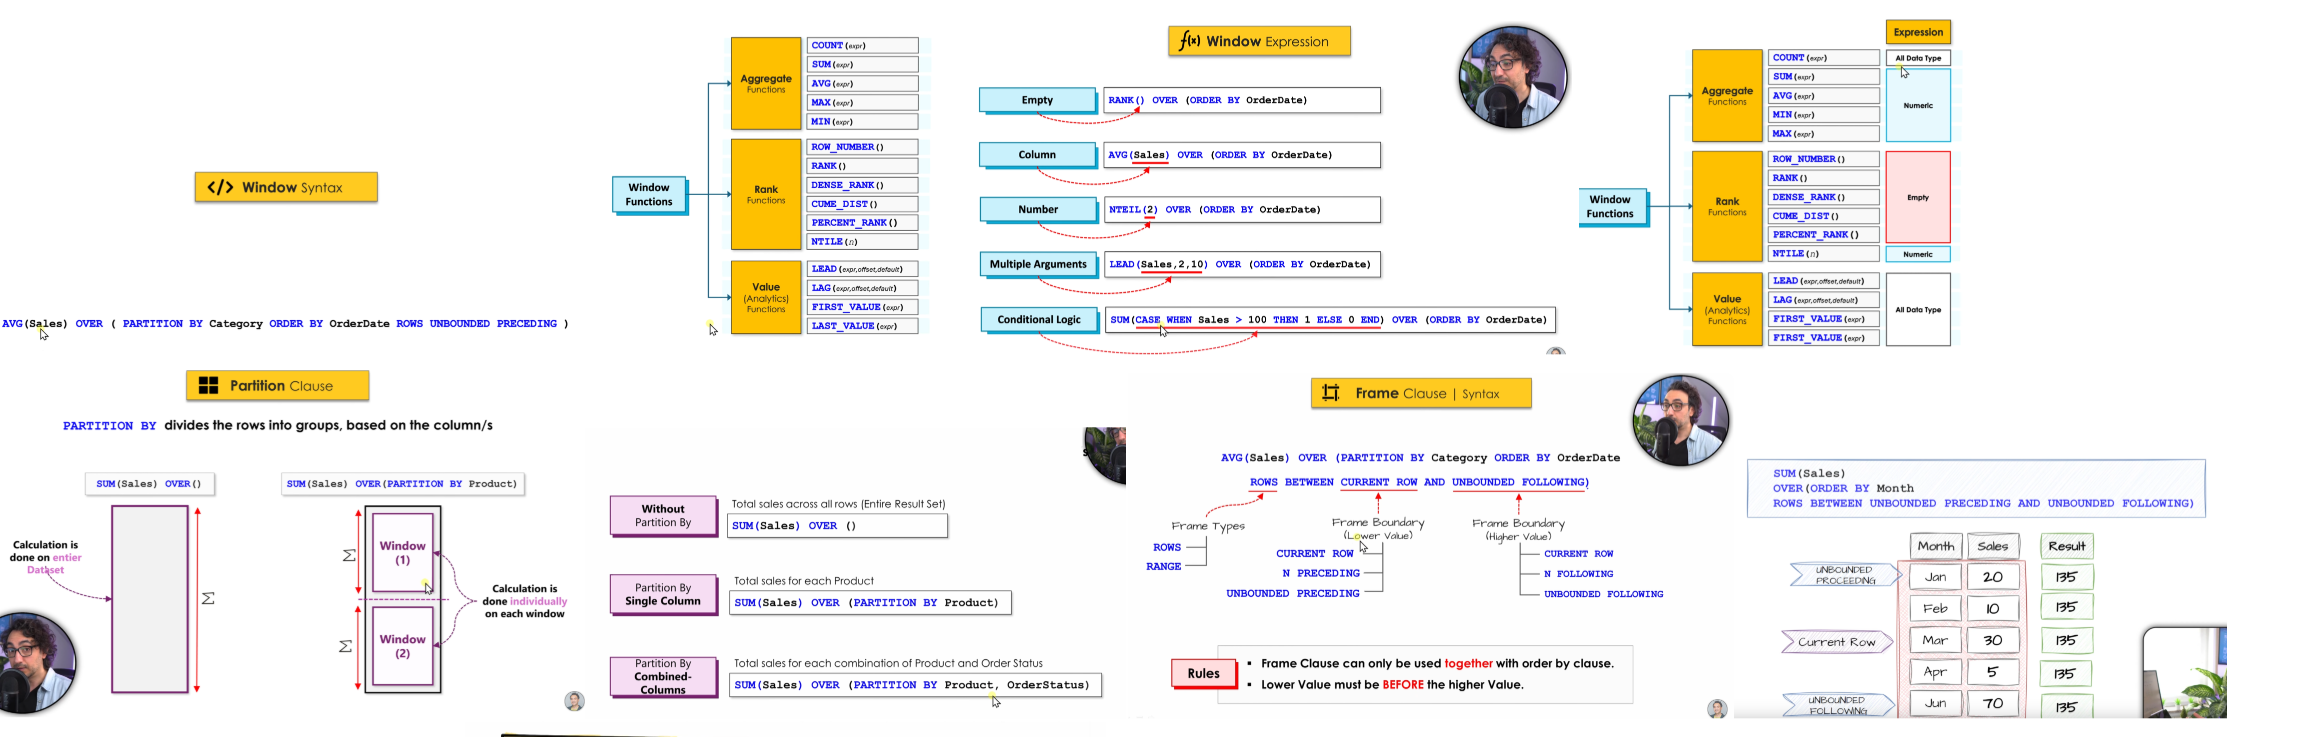

In [35]:
select_query: str = """
/* TASK 3: 
   Find the total sales across all orders,
   additionally providing details such as OrderID and OrderDate 
*/
SELECT
    OrderID,
    OrderDate,
    ProductID,
    Sales,
    SUM(Sales) OVER () AS Total_Sales
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


select_query: str = """
/* TASK 4: 
   Find the total sales across all orders and for each product,
   additionally providing details such as OrderID and OrderDate 
*/
SELECT
    OrderID,
    OrderDate,
    ProductID,
    Sales,
    SUM(Sales) OVER () AS Total_Sales,
    SUM(Sales) OVER (PARTITION BY ProductID) AS Sales_By_Product
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 5: 
   Find the total sales across all orders, for each product,
   and for each combination of product and order status,
   additionally providing details such as OrderID and OrderDate 
*/
SELECT
    OrderID,
    OrderDate,
    ProductID,
    OrderStatus,
    Sales,
    SUM(Sales) OVER () AS Total_Sales,
    SUM(Sales) OVER (PARTITION BY ProductID) AS Sales_By_Product,
    SUM(Sales) OVER (PARTITION BY ProductID, OrderStatus) AS Sales_By_Product_Status
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+------------+-----------+-------+-------------+
| OrderID | OrderDate  | ProductID | Sales | Total_Sales |
+---------+------------+-----------+-------+-------------+
|    1    | 2025-01-01 |    101    |  10   |     380     |
|    2    | 2025-01-05 |    102    |  15   |     380     |
|    3    | 2025-01-10 |    101    |  20   |     380     |
|    4    | 2025-01-20 |    105    |  60   |     380     |
|    5    | 2025-02-01 |    104    |  25   |     380     |
|    6    | 2025-02-05 |    104    |  50   |     380     |
|    7    | 2025-02-15 |    102    |  30   |     380     |
|    8    | 2025-02-18 |    101    |  90   |     380     |
|    9    | 2025-03-10 |    101    |  20   |     380     |
|   10    | 2025-03-15 |    102    |  60   |     380     |
+---------+------------+-----------+-------+-------------+
10 rows returned in time: (0.018 sec)


+---------+------------+-----------+-------+-------------+------------------+
| OrderID | OrderDate  | ProductID | Sales | Total_Sales

In [37]:
# RANK() must be used with ORDER BY 
select_query: str = """
/* TASK 6: 
   Rank each order by Sales from highest to lowest */
SELECT
    OrderID,
    OrderDate,
    Sales,
    RANK() OVER (ORDER BY Sales DESC) AS Rank_Sales
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


select_query: str = """
/* TASK 7: 
   Calculate Total Sales by Order Status for current and next two orders 
*/
SELECT
    OrderID,
    OrderDate,
    ProductID,
    OrderStatus,
    Sales,
    SUM(Sales) OVER (PARTITION BY OrderStatus ORDER BY OrderDate ROWS BETWEEN CURRENT ROW AND 2 FOLLOWING) AS Total_Sales
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 8: 
   Calculate Total Sales by Order Status for current and previous two orders 
*/
SELECT
    OrderID,
    OrderDate,
    ProductID,
    OrderStatus,
    Sales,
    SUM(Sales) OVER (
        PARTITION BY OrderStatus 
        ORDER BY OrderDate 
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS Total_Sales
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+------------+-------+------------+
| OrderID | OrderDate  | Sales | Rank_Sales |
+---------+------------+-------+------------+
|    8    | 2025-02-18 |  90   |     1      |
|    4    | 2025-01-20 |  60   |     2      |
|   10    | 2025-03-15 |  60   |     2      |
|    6    | 2025-02-05 |  50   |     4      |
|    7    | 2025-02-15 |  30   |     5      |
|    5    | 2025-02-01 |  25   |     6      |
|    9    | 2025-03-10 |  20   |     7      |
|    3    | 2025-01-10 |  20   |     7      |
|    2    | 2025-01-05 |  15   |     9      |
|    1    | 2025-01-01 |  10   |     10     |
+---------+------------+-------+------------+
10 rows returned in time: (0.001 sec)


+---------+------------+-----------+-------------+-------+-------------+
| OrderID | OrderDate  | ProductID | OrderStatus | Sales | Total_Sales |
+---------+------------+-----------+-------------+-------+-------------+
|    1    | 2025-01-01 |    101    |  Delivered  |  10   |     55      |
|    3    | 2025-01-10 |

In [38]:
select_query: str = """
/* TASK 9: 
   Calculate Total Sales by Order Status from previous two orders only 
*/
SELECT
    OrderID,
    OrderDate,
    ProductID,
    OrderStatus,
    Sales,
    SUM(Sales) OVER (
        PARTITION BY OrderStatus 
        ORDER BY OrderDate 
        ROWS 2 PRECEDING
    ) AS Total_Sales
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 10: 
   Calculate cumulative Total Sales by Order Status up to the current order 
*/
SELECT
    OrderID,
    OrderDate,
    ProductID,
    OrderStatus,
    Sales,
    SUM(Sales) OVER (
        PARTITION BY OrderStatus 
        ORDER BY OrderDate 
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS Total_Sales
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+------------+-----------+-------------+-------+-------------+
| OrderID | OrderDate  | ProductID | OrderStatus | Sales | Total_Sales |
+---------+------------+-----------+-------------+-------+-------------+
|    1    | 2025-01-01 |    101    |  Delivered  |  10   |     10      |
|    3    | 2025-01-10 |    101    |  Delivered  |  20   |     30      |
|    5    | 2025-02-01 |    104    |  Delivered  |  25   |     55      |
|    6    | 2025-02-05 |    104    |  Delivered  |  50   |     95      |
|    7    | 2025-02-15 |    102    |  Delivered  |  30   |     105     |
|    2    | 2025-01-05 |    102    |   Shipped   |  15   |     15      |
|    4    | 2025-01-20 |    105    |   Shipped   |  60   |     75      |
|    8    | 2025-02-18 |    101    |   Shipped   |  90   |     165     |
|    9    | 2025-03-10 |    101    |   Shipped   |  20   |     170     |
|   10    | 2025-03-15 |    102    |   Shipped   |  60   |     170     |
+---------+------------+-----------+-------------+-

In [39]:
select_query: str = """
/* TASK 11: 
   Calculate cumulative Total Sales by Order Status from the start to the current row 
*/
SELECT
    OrderID,
    OrderDate,
    ProductID,
    OrderStatus,
    Sales,
    SUM(Sales) OVER (
        PARTITION BY OrderStatus 
        ORDER BY OrderDate 
        ROWS UNBOUNDED PRECEDING
    ) AS Total_Sales
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK: 
   Find the total sales for each order status, only for two products 101 and 102
*/
SELECT
    OrderID,
    OrderDate,
    ProductID,
    OrderStatus,
    Sales,
    SUM(Sales) OVER (PARTITION BY OrderStatus) AS Total_Sales
FROM Sales.Orders
WHERE ProductID IN (101, 102);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+------------+-----------+-------------+-------+-------------+
| OrderID | OrderDate  | ProductID | OrderStatus | Sales | Total_Sales |
+---------+------------+-----------+-------------+-------+-------------+
|    1    | 2025-01-01 |    101    |  Delivered  |  10   |     10      |
|    3    | 2025-01-10 |    101    |  Delivered  |  20   |     30      |
|    5    | 2025-02-01 |    104    |  Delivered  |  25   |     55      |
|    6    | 2025-02-05 |    104    |  Delivered  |  50   |     105     |
|    7    | 2025-02-15 |    102    |  Delivered  |  30   |     135     |
|    2    | 2025-01-05 |    102    |   Shipped   |  15   |     15      |
|    4    | 2025-01-20 |    105    |   Shipped   |  60   |     75      |
|    8    | 2025-02-18 |    101    |   Shipped   |  90   |     165     |
|    9    | 2025-03-10 |    101    |   Shipped   |  20   |     185     |
|   10    | 2025-03-15 |    102    |   Shipped   |  60   |     245     |
+---------+------------+-----------+-------------+-

In [40]:
# - **RULE 4: Window Function can be used together with GROUP BY in the same query, ONLY if the same columns are used**

select_query: str = """
/* TASK 12: 
   Rank customers by their total sales 
*/
SELECT
    CustomerID,
    SUM(Sales) AS Total_Sales,
    RANK() OVER (ORDER BY SUM(Sales) DESC) AS Rank_Customers
FROM Sales.Orders
GROUP BY CustomerID;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 12: 
   Rank customers by their total sales 
*/
SELECT
    CustomerID,
    SUM(Sales) AS Total_Sales
FROM Sales.Orders
GROUP BY CustomerID;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-------------+----------------+
| CustomerID | Total_Sales | Rank_Customers |
+------------+-------------+----------------+
|     3      |     125     |       1        |
|     1      |     110     |       2        |
|     4      |     90      |       3        |
|     2      |     55      |       4        |
+------------+-------------+----------------+
4 rows returned in time: (0.029 sec)


+------------+-------------+
| CustomerID | Total_Sales |
+------------+-------------+
|     1      |     110     |
|     2      |     55      |
|     3      |     125     |
|     4      |     90      |
+------------+-------------+
4 rows returned in time: (0.01 sec)




In [41]:
select_query: str = """
/* TASK 1:
   Find the Total Number of Orders and the Total Number of Orders for Each Customer
*/
SELECT
    OrderID,
    OrderDate,
    CustomerID,
    COUNT(*) OVER() AS TotalOrders,
    COUNT(*) OVER(PARTITION BY CustomerID) AS OrdersByCustomers
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


select_query: str = """
/* TASK 2:
   - Find the Total Number of Customers
   - Find the Total Number of Scores for Customers
   - Find the Total Number of Countries
*/
SELECT
    *,
    COUNT(*) OVER () AS TotalCustomersStar,
    COUNT(1) OVER () AS TotalCustomersOne,
    COUNT(Score) OVER() AS TotalScores,
    COUNT(Country) OVER() AS TotalCountries
FROM Sales.Customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+------------+------------+-------------+-------------------+
| OrderID | OrderDate  | CustomerID | TotalOrders | OrdersByCustomers |
+---------+------------+------------+-------------+-------------------+
|    3    | 2025-01-10 |     1      |     10      |         3         |
|    4    | 2025-01-20 |     1      |     10      |         3         |
|    7    | 2025-02-15 |     1      |     10      |         3         |
|    1    | 2025-01-01 |     2      |     10      |         3         |
|    5    | 2025-02-01 |     2      |     10      |         3         |
|    9    | 2025-03-10 |     2      |     10      |         3         |
|   10    | 2025-03-15 |     3      |     10      |         3         |
|    6    | 2025-02-05 |     3      |     10      |         3         |
|    2    | 2025-01-05 |     3      |     10      |         3         |
|    8    | 2025-02-18 |     4      |     10      |         1         |
+---------+------------+------------+-------------+-------------

In [42]:
select_query: str = """
/* TASK 3:
   Check whether the table 'OrdersArchive' contains any duplicate rows based on the OrderID
*/
SELECT 
    * 
FROM (
    SELECT 
        *,
        COUNT(*) OVER(PARTITION BY OrderID) AS CheckDuplicates
    FROM Sales.OrdersArchive
) t
WHERE CheckDuplicates > 1
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


select_query: str = """
SELECT 
    *,
    COUNT(*) OVER(PARTITION BY OrderID) AS CheckDuplicates
FROM Sales.OrdersArchive
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+-----------+------------+---------------+------------+------------+-------------+------------------+---------------+----------+-------+---------------------+-----------------+
| OrderID | ProductID | CustomerID | SalesPersonID | OrderDate  |  ShipDate  | OrderStatus |   ShipAddress    |  BillAddress  | Quantity | Sales |    CreationTime     | CheckDuplicates |
+---------+-----------+------------+---------------+------------+------------+-------------+------------------+---------------+----------+-------+---------------------+-----------------+
|    4    |    105    |     1      |       3       | 2024-04-20 | 2024-04-25 |   Shipped   | 987 Victory Lane |               |    2     |  60   | 2024-04-20 05:50:33 |        2        |
|    4    |    105    |     1      |       3       | 2024-04-20 | 2024-04-25 |  Delivered  | 987 Victory Lane |               |    2     |  60   | 2024-04-20 14:50:33 |        2        |
|    6    |    104    |     3      |       5       | 2024-05-05 |

In [43]:
select_query: str = """
/* TASK 4:
   - Find the Total Sales Across All Orders 
   - Find the Total Sales for Each Product
*/
SELECT
    OrderID,
    OrderDate,
    Sales,
    ProductID,
    SUM(Sales) OVER () AS TotalSales,
    SUM(Sales) OVER (PARTITION BY ProductID) AS SalesByProduct
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 5:
   Find the Percentage Contribution of Each Product's Sales to the Total Sales
*/
SELECT
    OrderID,
    ProductID,
    Sales,
    SUM(Sales) OVER () AS TotalSales,
    ROUND(CAST(Sales AS FLOAT) / SUM(Sales) OVER () * 100, 2) AS PercentageOfTotal
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+------------+-------+-----------+------------+----------------+
| OrderID | OrderDate  | Sales | ProductID | TotalSales | SalesByProduct |
+---------+------------+-------+-----------+------------+----------------+
|    1    | 2025-01-01 |  10   |    101    |    380     |      140       |
|    3    | 2025-01-10 |  20   |    101    |    380     |      140       |
|    8    | 2025-02-18 |  90   |    101    |    380     |      140       |
|    9    | 2025-03-10 |  20   |    101    |    380     |      140       |
|   10    | 2025-03-15 |  60   |    102    |    380     |      105       |
|    2    | 2025-01-05 |  15   |    102    |    380     |      105       |
|    7    | 2025-02-15 |  30   |    102    |    380     |      105       |
|    5    | 2025-02-01 |  25   |    104    |    380     |       75       |
|    6    | 2025-02-05 |  50   |    104    |    380     |       75       |
|    4    | 2025-01-20 |  60   |    105    |    380     |       60       |
+---------+------------+-

In [44]:
select_query: str = """
/* TASK:
   - Check whether the table 'orders' contains any duplicate rows
*/
SELECT
    OrderID,
    COUNT(*) OVER (PARTITION BY OrderID) AS CheckPK
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+---------+
| OrderID | CheckPK |
+---------+---------+
|    1    |    1    |
|    2    |    1    |
|    3    |    1    |
|    4    |    1    |
|    5    |    1    |
|    6    |    1    |
|    7    |    1    |
|    8    |    1    |
|    9    |    1    |
|   10    |    1    |
+---------+---------+
10 rows returned in time: (0.016 sec)




In [45]:
select_query: str = """
/* TASK 6:
   - Find the Average Sales Across All Orders 
   - Find the Average Sales for Each Product
*/
SELECT
    OrderID,
    OrderDate,
    Sales,
    ProductID,
    AVG(Sales) OVER () AS AvgSales,
    AVG(Sales) OVER (PARTITION BY ProductID) AS AvgSalesByProduct
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 7:
   Find the Average Scores of Customers
*/
SELECT
    CustomerID,
    LastName,
    Score,
    COALESCE(Score, 0) AS CustomerScore,
    AVG(Score) OVER () AS AvgScore,
    AVG(COALESCE(Score, 0)) OVER () AS AvgScoreWithoutNull
FROM Sales.Customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


select_query: str = """
/* TASK 8:
   Find all orders where Sales exceed the average Sales across all orders
*/
SELECT
    *
FROM (
    SELECT
        OrderID,
        ProductID,
        Sales,
        AVG(Sales) OVER () AS Avg_Sales
    FROM Sales.Orders
) t 
WHERE Sales > Avg_Sales
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 8:
   Find all orders where Sales exceed the average Sales across all orders
*/
SELECT
    OrderID,
    ProductID,
    Sales
FROM Sales.Orders
WHERE Sales > (SELECT AVG(Sales) FROM Sales.Orders)
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+------------+-------+-----------+----------+-------------------+
| OrderID | OrderDate  | Sales | ProductID | AvgSales | AvgSalesByProduct |
+---------+------------+-------+-----------+----------+-------------------+
|    1    | 2025-01-01 |  10   |    101    |    38    |        35         |
|    3    | 2025-01-10 |  20   |    101    |    38    |        35         |
|    8    | 2025-02-18 |  90   |    101    |    38    |        35         |
|    9    | 2025-03-10 |  20   |    101    |    38    |        35         |
|   10    | 2025-03-15 |  60   |    102    |    38    |        35         |
|    2    | 2025-01-05 |  15   |    102    |    38    |        35         |
|    7    | 2025-02-15 |  30   |    102    |    38    |        35         |
|    5    | 2025-02-01 |  25   |    104    |    38    |        37         |
|    6    | 2025-02-05 |  50   |    104    |    38    |        37         |
|    4    | 2025-01-20 |  60   |    105    |    38    |        60         |
+---------+-

In [46]:
select_query: str = """
/* TASK 9:
   Find the Highest and Lowest Sales across all orders
*/
SELECT 
    MIN(Sales) AS MinSales, 
    MAX(Sales) AS MaxSales 
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 10:
   Find the Lowest Sales across all orders and by Product
*/
SELECT 
    OrderID,
    ProductID,
    OrderDate,
    Sales,
    MIN(Sales) OVER () AS LowestSales,
    MIN(Sales) OVER (PARTITION BY ProductID) AS LowestSalesByProduct
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+----------+----------+
| MinSales | MaxSales |
+----------+----------+
|    10    |    90    |
+----------+----------+
1 row returned in time: (0.002 sec)


+---------+-----------+------------+-------+-------------+----------------------+
| OrderID | ProductID | OrderDate  | Sales | LowestSales | LowestSalesByProduct |
+---------+-----------+------------+-------+-------------+----------------------+
|    1    |    101    | 2025-01-01 |  10   |     10      |          10          |
|    3    |    101    | 2025-01-10 |  20   |     10      |          10          |
|    8    |    101    | 2025-02-18 |  90   |     10      |          10          |
|    9    |    101    | 2025-03-10 |  20   |     10      |          10          |
|   10    |    102    | 2025-03-15 |  60   |     10      |          15          |
|    2    |    102    | 2025-01-05 |  15   |     10      |          15          |
|    7    |    102    | 2025-02-15 |  30   |     10      |          15          |
|    5    |    104    

In [47]:
select_query: str = """
/* TASK 11:
   Show the employees who have the highest salaries
*/
SELECT *
FROM (
	SELECT *,
		   MAX(Salary) OVER() AS HighestSalary
	FROM Sales.Employees
) t
WHERE Salary = HighestSalary
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


select_query: str = """
/* TASK 12:
   Find the deviation of each Sale from the minimum and maximum Sales
*/
SELECT
    OrderID,
    OrderDate,
    ProductID,
    Sales,
    MAX(Sales) OVER () AS HighestSales,
    MIN(Sales) OVER () AS LowestSales,
    Sales - MIN(Sales) OVER () AS DeviationFromMin,
    MAX(Sales) OVER () - Sales AS DeviationFromMax
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-----------+----------+------------+------------+--------+--------+-----------+---------------+
| EmployeeID | FirstName | LastName | Department | BirthDate  | Gender | Salary | ManagerID | HighestSalary |
+------------+-----------+----------+------------+------------+--------+--------+-----------+---------------+
|     4      |  Michael  |   Ray    |   Sales    | 1977-02-10 |   M    | 90000  |     2     |     90000     |
+------------+-----------+----------+------------+------------+--------+--------+-----------+---------------+
1 row returned in time: (0.015 sec)


+---------+------------+-----------+-------+--------------+-------------+------------------+------------------+
| OrderID | OrderDate  | ProductID | Sales | HighestSales | LowestSales | DeviationFromMin | DeviationFromMax |
+---------+------------+-----------+-------+--------------+-------------+------------------+------------------+
|    1    | 2025-01-01 |    101    |  10   |      90      |     10      |   

In [48]:
# ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW ---- DEFAULT
select_query: str = """
/* TASK 13:
   Calculate the moving average of Sales for each Product over time
*/
SELECT
    OrderID,
    ProductID,
    OrderDate,
    Sales,
    AVG(Sales) OVER (PARTITION BY ProductID) AS AvgByProduct,
    AVG(Sales) OVER (PARTITION BY ProductID ORDER BY OrderDate) AS MovingAvg
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 13:
   Calculate the moving average of Sales for each Product over time
*/
SELECT
    OrderID,
    ProductID,
    OrderDate,
    Sales,
    AVG(Sales) OVER (PARTITION BY ProductID) AS AvgByProduct,
    AVG(Sales) OVER (PARTITION BY ProductID ORDER BY OrderDate ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS MovingAvg
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+-----------+------------+-------+--------------+-----------+
| OrderID | ProductID | OrderDate  | Sales | AvgByProduct | MovingAvg |
+---------+-----------+------------+-------+--------------+-----------+
|    1    |    101    | 2025-01-01 |  10   |      35      |    10     |
|    3    |    101    | 2025-01-10 |  20   |      35      |    15     |
|    8    |    101    | 2025-02-18 |  90   |      35      |    40     |
|    9    |    101    | 2025-03-10 |  20   |      35      |    35     |
|    2    |    102    | 2025-01-05 |  15   |      35      |    15     |
|    7    |    102    | 2025-02-15 |  30   |      35      |    22     |
|   10    |    102    | 2025-03-15 |  60   |      35      |    35     |
|    5    |    104    | 2025-02-01 |  25   |      37      |    25     |
|    6    |    104    | 2025-02-05 |  50   |      37      |    37     |
|    4    |    105    | 2025-01-20 |  60   |      60      |    60     |
+---------+-----------+------------+-------+--------------+-----

In [49]:
select_query: str = """
/* TASK 14:
   Calculate the moving average of Sales for each Product over time,
   including only the next order
*/
SELECT
    OrderID,
    ProductID,
    OrderDate,
    Sales,
    AVG(Sales) OVER (PARTITION BY ProductID ORDER BY OrderDate ROWS BETWEEN CURRENT ROW AND 1 FOLLOWING) AS RollingAvg
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+-----------+------------+-------+------------+
| OrderID | ProductID | OrderDate  | Sales | RollingAvg |
+---------+-----------+------------+-------+------------+
|    1    |    101    | 2025-01-01 |  10   |     15     |
|    3    |    101    | 2025-01-10 |  20   |     55     |
|    8    |    101    | 2025-02-18 |  90   |     55     |
|    9    |    101    | 2025-03-10 |  20   |     20     |
|    2    |    102    | 2025-01-05 |  15   |     22     |
|    7    |    102    | 2025-02-15 |  30   |     45     |
|   10    |    102    | 2025-03-15 |  60   |     60     |
|    5    |    104    | 2025-02-01 |  25   |     37     |
|    6    |    104    | 2025-02-05 |  50   |     50     |
|    4    |    105    | 2025-01-20 |  60   |     60     |
+---------+-----------+------------+-------+------------+
10 rows returned in time: (0.004 sec)




In [50]:
print("TASK 1:Rank Orders Based on Sales from Highest to Lowest")
select_query = """
/* TASK 1:
   Rank Orders Based on Sales from Highest to Lowest
*/
SELECT
    OrderID,
    ProductID,
    Sales,
    ROW_NUMBER() OVER (ORDER BY Sales DESC) AS SalesRank_Row,
    RANK() OVER (ORDER BY Sales DESC) AS SalesRank_Rank,
    DENSE_RANK() OVER (ORDER BY Sales DESC) AS SalesRank_Dense
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


print("TASK 1:Rank Orders Based on Sales from Highest to Lowest based on ProductID")
select_query = """
/* TASK 1:
   Rank Orders Based on Sales from Highest to Lowest based on ProductID
*/
SELECT
    OrderID,
    ProductID,
    Sales,
    ROW_NUMBER() OVER (PARTITION BY ProductID ORDER BY Sales DESC) AS SalesRank_Row,
    RANK() OVER (PARTITION BY ProductID ORDER BY Sales DESC) AS SalesRank_Rank,
    DENSE_RANK() OVER (PARTITION BY ProductID ORDER BY Sales DESC) AS SalesRank_Dense
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


print("TASK 2:Use Case | Top-N Analysis: Find the Highest Sale for Each Product")
select_query = """
/* TASK 2:
   Use Case | Top-N Analysis: Find the Highest Sale for Each Product
*/
SELECT *
FROM (
    SELECT
        OrderID,
        ProductID,
        Sales,
        ROW_NUMBER() OVER (PARTITION BY ProductID ORDER BY Sales DESC) AS RankByProduct
    FROM Sales.Orders
) AS TopProductSales
WHERE RankByProduct = 1;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query = """
SELECT
    OrderID,
    ProductID,
    Sales,
    ROW_NUMBER() OVER (PARTITION BY ProductID ORDER BY Sales DESC) AS RankByProduct
FROM Sales.Orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

TASK 1:Rank Orders Based on Sales from Highest to Lowest
+---------+-----------+-------+---------------+----------------+-----------------+
| OrderID | ProductID | Sales | SalesRank_Row | SalesRank_Rank | SalesRank_Dense |
+---------+-----------+-------+---------------+----------------+-----------------+
|    8    |    101    |  90   |       1       |       1        |        1        |
|    4    |    105    |  60   |       2       |       2        |        2        |
|   10    |    102    |  60   |       3       |       2        |        2        |
|    6    |    104    |  50   |       4       |       4        |        3        |
|    7    |    102    |  30   |       5       |       5        |        4        |
|    5    |    104    |  25   |       6       |       6        |        5        |
|    9    |    101    |  20   |       7       |       7        |        6        |
|    3    |    101    |  20   |       8       |       7        |        6        |
|    2    |    102    |  15   

In [52]:
print("TASK 3:Use Case | Bottom-N Analysis: Find the Lowest 2 Customers Based on Their Total Sales")
select_query = """
/* TASK 3:
   Use Case | Bottom-N Analysis: Find the Lowest 2 Customers Based on Their Total Sales
*/
SELECT *
FROM (
    SELECT
        CustomerID,
        SUM(Sales) AS TotalSales,
        ROW_NUMBER() OVER (ORDER BY SUM(Sales)) AS RankCustomers
    FROM Sales.Orders
    GROUP BY CustomerID
) AS BottomCustomerSales
WHERE RankCustomers <= 2;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query = """
SELECT
    TOP 2
    CustomerID,
    SUM(Sales) AS TotalSales
FROM Sales.Orders
GROUP BY CustomerID
ORDER BY TotalSales ASC;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

print("TASK 4:Use Case | Assign Unique IDs to the Rows of the 'Order Archive'")
select_query = """
/* TASK 4:
   Use Case | Assign Unique IDs to the Rows of the 'Order Archive'
*/
SELECT
    ROW_NUMBER() OVER (ORDER BY OrderID, OrderDate) AS UniqueID,
    *
FROM Sales.OrdersArchive;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

TASK 3:Use Case | Bottom-N Analysis: Find the Lowest 2 Customers Based on Their Total Sales
+------------+------------+---------------+
| CustomerID | TotalSales | RankCustomers |
+------------+------------+---------------+
|     2      |     55     |       1       |
|     4      |     90     |       2       |
+------------+------------+---------------+
2 rows returned in time: (0.001 sec)


+------------+------------+
| CustomerID | TotalSales |
+------------+------------+
|     2      |     55     |
|     4      |     90     |
+------------+------------+
2 rows returned in time: (0.0 sec)


TASK 4:Use Case | Assign Unique IDs to the Rows of the 'Order Archive'
+----------+---------+-----------+------------+---------------+------------+------------+-------------+------------------+----------------+----------+-------+---------------------+
| UniqueID | OrderID | ProductID | CustomerID | SalesPersonID | OrderDate  |  ShipDate  | OrderStatus |   ShipAddress    |  BillAddress   | Quantity

In [53]:
print("TASK 6:Divide Orders into Groups Based on Sales")
select_query = """
/* TASK 6:
   Divide Orders into Groups Based on Sales
*/
SELECT 
    OrderID,
    Sales,
    NTILE(1) OVER (ORDER BY Sales) AS OneBucket,
    NTILE(2) OVER (ORDER BY Sales) AS TwoBuckets,
    NTILE(3) OVER (ORDER BY Sales) AS ThreeBuckets,
    NTILE(4) OVER (ORDER BY Sales) AS FourBuckets
    -- NTILE(2) OVER (PARTITION BY ProductID ORDER BY Sales) AS TwoBucketByProducts
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query = """
/* TASK 6:
   Divide Orders into Groups Based on Sales
*/
SELECT 
    OrderID,
    ProductID,
    Sales,
    NTILE(2) OVER (PARTITION BY ProductID ORDER BY Sales DESC) AS TwoBucketByProducts
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

print("TASK 7:Segment all Orders into 3 Categories: High, Medium, and Low Sales")
select_query = """
/* TASK 7:
   Segment all Orders into 3 Categories: High, Medium, and Low Sales.
*/
SELECT
    OrderID,
    ProductID,
    Sales,
    Buckets,
    CASE 
        WHEN Buckets = 1 THEN 'High'
        WHEN Buckets = 2 THEN 'Medium'
        WHEN Buckets = 3 THEN 'Low'
    END AS SalesSegmentations
FROM (
    SELECT
        OrderID,
        ProductID,
        Sales,
        NTILE(3) OVER (ORDER BY Sales DESC) AS Buckets
    FROM Sales.Orders
) AS SalesBuckets;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

TASK 6:Divide Orders into Groups Based on Sales
+---------+-------+-----------+------------+--------------+-------------+
| OrderID | Sales | OneBucket | TwoBuckets | ThreeBuckets | FourBuckets |
+---------+-------+-----------+------------+--------------+-------------+
|    1    |  10   |     1     |     1      |      1       |      1      |
|    2    |  15   |     1     |     1      |      1       |      1      |
|    3    |  20   |     1     |     1      |      1       |      1      |
|    9    |  20   |     1     |     1      |      1       |      2      |
|    5    |  25   |     1     |     1      |      2       |      2      |
|    7    |  30   |     1     |     2      |      2       |      2      |
|    6    |  50   |     1     |     2      |      2       |      3      |
|    4    |  60   |     1     |     2      |      3       |      3      |
|   10    |  60   |     1     |     2      |      3       |      4      |
|    8    |  90   |     1     |     2      |      3       |     

In [54]:
print("TASK 8:Divide Orders into Groups for Processing")
select_query = """
/* TASK 8:
   Divide Orders into Groups for Processing
*/
SELECT 
    NTILE(5) OVER (ORDER BY OrderID) AS Buckets,
    *
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

TASK 8:Divide Orders into Groups for Processing
+---------+---------+-----------+------------+---------------+------------+------------+-------------+--------------------+---------------+----------+-------+---------------------+
| Buckets | OrderID | ProductID | CustomerID | SalesPersonID | OrderDate  |  ShipDate  | OrderStatus |    ShipAddress     |  BillAddress  | Quantity | Sales |    CreationTime     |
+---------+---------+-----------+------------+---------------+------------+------------+-------------+--------------------+---------------+----------+-------+---------------------+
|    1    |    1    |    101    |     2      |       3       | 2025-01-01 | 2025-01-05 |  Delivered  | 9833 Mt. Dias Blv. | 1226 Shoe St. |    1     |  10   | 2025-01-01 12:34:56 |
|    1    |    2    |    102    |     3      |       3       | 2025-01-05 | 2025-01-10 |   Shipped   |   250 Race Court   |     NULL      |    1     |  15   | 2025-01-05 23:22:04 |
|    2    |    3    |    101    |     1      | 

In [55]:
print("TASK 9:Find Products that Fall Within the Highest 40% of the Prices")
select_query = """
/* TASK 9:
   Find Products that Fall Within the Highest 40% of the Prices
*/
SELECT 
    Product,
    Price,
    DistRank,
    CONCAT(DistRank * 100, '%') AS DistRankPerc
FROM (
    SELECT
        Product,
        Price,
        CUME_DIST() OVER (ORDER BY Price DESC) AS DistRank
    FROM Sales.Products
) AS PriceDistribution
WHERE DistRank <= 0.4;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query = """
SELECT
    Product,
    Price,
    CUME_DIST() OVER (ORDER BY Price DESC) AS DistRank
FROM Sales.Products;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

TASK 9:Find Products that Fall Within the Highest 40% of the Prices
+---------+-------+----------+--------------+
| Product | Price | DistRank | DistRankPerc |
+---------+-------+----------+--------------+
| Gloves  |  30   |   0.2    |     20%      |
|  Caps   |  25   |   0.4    |     40%      |
+---------+-------+----------+--------------+
2 rows returned in time: (0.014 sec)


+---------+-------+----------+
| Product | Price | DistRank |
+---------+-------+----------+
| Gloves  |  30   |   0.2    |
|  Caps   |  25   |   0.4    |
|  Socks  |  20   |   0.6    |
|  Tire   |  15   |   0.8    |
| Bottle  |  10   |   1.0    |
+---------+-------+----------+
5 rows returned in time: (0.004 sec)




In [56]:
print("TASK 1:Analyze the Month-over-Month Performance by Finding the Percentage Change in Sales Between the Current and Previous Months")
select_query = """
/* TASK 1:
   Analyze the Month-over-Month Performance by Finding the Percentage Change in Sales
   Between the Current and Previous Months
*/
SELECT
    *,
    CurrentMonthSales - PreviousMonthSales AS MoM_Change,
    ROUND(
        CAST((CurrentMonthSales - PreviousMonthSales) AS FLOAT)
        / PreviousMonthSales * 100, 1) AS MoM_Perc
FROM (
    SELECT
        MONTH(OrderDate) AS OrderMonth,
        SUM(Sales) AS CurrentMonthSales,
        LAG(SUM(Sales)) OVER (ORDER BY MONTH(OrderDate)) AS PreviousMonthSales
    FROM Sales.Orders
    GROUP BY MONTH(OrderDate)
) AS MonthlySales;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


select_query = """
SELECT
    MONTH(OrderDate) AS OrderMonth,
    SUM(Sales) AS CurrentMonthSales,
    LAG(SUM(Sales)) OVER (ORDER BY MONTH(OrderDate)) AS PreviousMonthSales
FROM Sales.Orders
GROUP BY MONTH(OrderDate)
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

TASK 1:Analyze the Month-over-Month Performance by Finding the Percentage Change in Sales Between the Current and Previous Months
+------------+-------------------+--------------------+------------+----------+
| OrderMonth | CurrentMonthSales | PreviousMonthSales | MoM_Change | MoM_Perc |
+------------+-------------------+--------------------+------------+----------+
|     1      |        105        |        NULL        |    NULL    |   NULL   |
|     2      |        195        |        105         |     90     |   85.7   |
|     3      |        80         |        195         |    -115    |  -59.0   |
+------------+-------------------+--------------------+------------+----------+
3 rows returned in time: (0.012 sec)


+------------+-------------------+--------------------+
| OrderMonth | CurrentMonthSales | PreviousMonthSales |
+------------+-------------------+--------------------+
|     1      |        105        |        NULL        |
|     2      |        195        |        105  

In [57]:
print("TASK 2:Customer Loyalty Analysis - Rank Customers Based on the Average Days Between Their Orders")
select_query = """
/* TASK 2:
   Customer Loyalty Analysis - Rank Customers Based on the Average Days Between Their Orders
*/
SELECT
    CustomerID,
    AVG(DaysUntilNextOrder) AS AvgDays,
    RANK() OVER (ORDER BY COALESCE(AVG(DaysUntilNextOrder), 999999)) AS RankAvg
FROM (
    SELECT
        OrderID,
        CustomerID,
        OrderDate AS CurrentOrder,
        LEAD(OrderDate) OVER (PARTITION BY CustomerID ORDER BY OrderDate) AS NextOrder,
        DATEDIFF(
            day,
            OrderDate,
            LEAD(OrderDate) OVER (PARTITION BY CustomerID ORDER BY OrderDate)
        ) AS DaysUntilNextOrder
    FROM Sales.Orders
) AS CustomerOrdersWithNext
GROUP BY CustomerID;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query = """
SELECT
    OrderID,
    CustomerID,
    OrderDate AS CurrentOrder,
    LEAD(OrderDate) OVER (PARTITION BY CustomerID ORDER BY OrderDate) AS NextOrder,
    DATEDIFF(
        day,
        OrderDate,
        LEAD(OrderDate) OVER (PARTITION BY CustomerID ORDER BY OrderDate)
    ) AS DaysUntilNextOrder
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

TASK 2:Customer Loyalty Analysis - Rank Customers Based on the Average Days Between Their Orders
+------------+---------+---------+
| CustomerID | AvgDays | RankAvg |
+------------+---------+---------+
|     1      |   18    |    1    |
|     2      |   34    |    2    |
|     3      |   34    |    2    |
|     4      |  NULL   |    4    |
+------------+---------+---------+
4 rows returned in time: (0.02 sec)


+---------+------------+--------------+------------+--------------------+
| OrderID | CustomerID | CurrentOrder | NextOrder  | DaysUntilNextOrder |
+---------+------------+--------------+------------+--------------------+
|    3    |     1      |  2025-01-10  | 2025-01-20 |         10         |
|    4    |     1      |  2025-01-20  | 2025-02-15 |         26         |
|    7    |     1      |  2025-02-15  |    NULL    |        NULL        |
|    1    |     2      |  2025-01-01  | 2025-02-01 |         31         |
|    5    |     2      |  2025-02-01  | 2025-03-10 |         37    